In [149]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## Funções de auditoria

Funções reutilizadas ao longo do notebook para relatório inicial (pré-avaliação) e relatório final (comparativo antes/depois) de cada base.

In [150]:
def relatorio_inicial(df):
    """
    PRE AVALIACAO DA BASE
    """
    print("=" * 48)
    print(f"ETAPA 1 - AUDITORIA")
    print("=" * 48)
    
    print("\n[1] COLUNAS DA BASE:")
    print(df.columns.tolist())
    
    print("\n[2] INFO DA BASE:")
    df.info()
    
    print("\n[3] TIPOS DE DADOS (dtypes):")
    print(df.dtypes)
    
    print("\n[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):")
    print(df.describe())

    '''print("\n[5] ESTATÍSTICAS DESCRITIVAS (Objetos/Texto): ")
    try:
        print(df.describe(include='object'))
    except ValueError:
        print("Não há colunas de texto nesta base.")'''
    
    print("\n[6] QUANTIDADE DE NULOS POR COLUNA:")
    print(df.isnull().sum())
     
    print("\n[8] PERCENTUAL DE NULOS (> 15%):")
    percentual_nulos = (df.isnull().sum() / len(df) * 100).round(1)
    print(percentual_nulos)
        
    print("\n[9] LINHAS COM VALORES NULOS:")
    qtd_nulos_linhas = df.isnull().any(axis=1).sum()
    print(f"Total de linhas com pelo menos um valor nulo: {qtd_nulos_linhas}")
    
    print("\n[10] TOTAL DE LINHAS DUPLICADAS:")
    total_duplicadas = df.duplicated().sum()
    print(f"Total: {total_duplicadas}")
    
    print("\n" + "=" * 48)
    print(f"FIM DO RELATÓRIO")
    print("=" * 48 + "\n")

def relatorio_final(df_original, df_atual):
    """
    RELATÓRIO FINAL DE AUDITORIA
    """
    registros_iniciais = df_original.shape[0]
    registros_finais = df_atual.shape[0]
    colunas_iniciais = df_original.shape[1]
    colunas_finais = df_atual.shape[1]

    print('=' * 48)
    print('      RELATÓRIO FINAL DE AUDITORIA')
    print('=' * 48)
    print(f'Registros iniciais:     {registros_iniciais:>6}')
    print(f'Registros finais:       {registros_finais:>6}')
    print(f'Registros removidos:    {registros_iniciais - registros_finais:>6}')
    print(f'Colunas originais:      {colunas_iniciais:>6}')
    print(f'Colunas finais:         {colunas_finais:>6}')
    print('=' * 48)
    print(f'Nulos restantes:        {df_atual.isnull().sum().sum():>6}')
    print(f'Duplicatas restantes:   {df_atual.duplicated().sum():>6}')
    print('=' * 48)

## Convertendo as bases em DataFrame

Leitura dos CSVs originais e concatenação com as bases complementares (clientes, quartos, funcionários, reservas e unidades novos).

In [151]:
canais = pd.read_csv('canais_venda.csv', sep=';', encoding='utf-8')
clientes = pd.read_csv('clientes.csv', sep=';', encoding='utf-8')
funcionarios = pd.read_csv('funcionarios.csv', sep=';', encoding='utf-8')
reservas = pd.read_csv('reservas.csv', sep=';', encoding='utf-8')
quartos = pd.read_csv('tipos_quarto.csv', sep=';', encoding='utf-8')
unidades = pd.read_csv('unidades.csv', sep=';', encoding='utf-8')


clientes_novos=pd.read_csv('clientes_novos.csv', sep=';', encoding='utf-8')
df_concatenado_clientes = pd.concat([clientes, clientes_novos], ignore_index=True)

quartos_novos=pd.read_csv('tipos_quarto_novos.csv', sep=';', encoding='utf-8')
df_concatenado_quartos = pd.concat([quartos, quartos_novos], ignore_index=True)

funcionarios_novos=pd.read_csv('funcionarios_novos.csv', sep=';', encoding='utf-8')
df_concatenado_funcionarios = pd.concat([funcionarios, funcionarios_novos], ignore_index=True)

reservas_novos=pd.read_csv('reservas_novas.csv', sep=';', encoding='utf-8')
df_concatenado_reservas = pd.concat([reservas, reservas_novos], ignore_index=True)

unidades_total=pd.read_csv('unidades_novos.csv', sep=';', encoding='utf-8')

df_concatenado_unidades = pd.concat([unidades, unidades_total], ignore_index=True)

In [152]:
canais_original = canais.copy()
df_concatenado_unidades_original = df_concatenado_unidades.copy()
df_concatenado_clientes_original = df_concatenado_clientes.copy()
df_concatenado_funcionarios_original = df_concatenado_funcionarios.copy()
df_concatenado_quartos_original = df_concatenado_quartos.copy()
df_concatenado_reservas_original = df_concatenado_reservas.copy()

* Criando as cópias para o relatório final/arquivo

## Etapa 1 — Auditoria

Aplica a função `relatorio_inicial` para identificar inconsistências antes da limpeza em todas as bases.

In [153]:
relatorio_inicial (canais)


ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_canal', 'nome_canal', 'comissao_pct']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id_canal      4 non-null      int64
 1   nome_canal    4 non-null      str  
 2   comissao_pct  4 non-null      str  
dtypes: int64(1), str(2)
memory usage: 228.0 bytes

[3] TIPOS DE DADOS (dtypes):
id_canal        int64
nome_canal        str
comissao_pct      str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_canal
count  4.000000
mean   2.500000
std    1.290994
min    1.000000
25%    1.750000
50%    2.500000
75%    3.250000
max    4.000000

[6] QUANTIDADE DE NULOS POR COLUNA:
id_canal        0
nome_canal      0
comissao_pct    0
dtype: int64

[8] PERCENTUAL DE NULOS (> 15%):
id_canal        0.0
nome_canal      0.0
comissao_pct    0.0
dtype: float64

[9] LINHAS COM VALORES NULOS:
Total de l

In [154]:
relatorio_inicial (funcionarios)


ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_funcionario', 'id_unidade', 'nome', 'cargo', 'departamento', 'salario', 'data_admissao']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id_funcionario  134 non-null    int64
 1   id_unidade      134 non-null    int64
 2   nome            134 non-null    str  
 3   cargo           134 non-null    str  
 4   departamento    134 non-null    str  
 5   salario         128 non-null    str  
 6   data_admissao   134 non-null    str  
dtypes: int64(2), str(5)
memory usage: 7.5 KB

[3] TIPOS DE DADOS (dtypes):
id_funcionario    int64
id_unidade        int64
nome                str
cargo               str
departamento        str
salario             str
data_admissao       str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_funcionario  id_unidade
count      134.000000  134.000

In [155]:
relatorio_inicial(reservas)


ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_reserva', 'id_unidade', 'id_tipo_quarto', 'id_cliente', 'id_canal', 'data_checkin', 'data_checkout', 'qtd_diarias', 'num_hospedes', 'avaliacao_hospede', 'status_reserva', 'forma_pagamento']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_reserva         2457 non-null   int64  
 1   id_unidade         2457 non-null   int64  
 2   id_tipo_quarto     2457 non-null   int64  
 3   id_cliente         2457 non-null   int64  
 4   id_canal           2345 non-null   float64
 5   data_checkin       2457 non-null   str    
 6   data_checkout      2457 non-null   str    
 7   qtd_diarias        2457 non-null   int64  
 8   num_hospedes       2457 non-null   int64  
 9   avaliacao_hospede  2120 non-null   float64
 10  status_reserva     2457 non-null   str    
 11  forma_pagamento    

In [156]:
relatorio_inicial(quartos)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_tipo_quarto', 'descricao', 'capacidade_max', 'valor_diaria_base']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_tipo_quarto     6 non-null      int64
 1   descricao          6 non-null      str  
 2   capacidade_max     6 non-null      int64
 3   valor_diaria_base  6 non-null      str  
dtypes: int64(2), str(2)
memory usage: 324.0 bytes

[3] TIPOS DE DADOS (dtypes):
id_tipo_quarto       int64
descricao              str
capacidade_max       int64
valor_diaria_base      str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_tipo_quarto  capacidade_max
count        6.000000        6.000000
mean         3.000000        3.000000
std          1.414214        0.894427
min          1.000000        2.000000
25%          2.250000        2.250000
50%          3.000000        

In [157]:
relatorio_inicial(unidades)


ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_unidade', 'nome_unidade', 'cidade', 'regiao', 'categoria_hotel', 'num_quartos_total']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_unidade         12 non-null     int64  
 1   nome_unidade       12 non-null     str    
 2   cidade             12 non-null     str    
 3   regiao             12 non-null     str    
 4   categoria_hotel    12 non-null     str    
 5   num_quartos_total  10 non-null     float64
dtypes: float64(1), int64(1), str(4)
memory usage: 708.0 bytes

[3] TIPOS DE DADOS (dtypes):
id_unidade             int64
nome_unidade             str
cidade                   str
regiao                   str
categoria_hotel          str
num_quartos_total    float64
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_unidade  num_quartos_total
count   12.0

In [158]:
relatorio_inicial(clientes_novos)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_cliente', 'nome', 'cidade_origem', 'estado_origem', 'faixa_etaria', 'tipo_cliente']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_cliente     20 non-null     int64
 1   nome           20 non-null     str  
 2   cidade_origem  20 non-null     str  
 3   estado_origem  20 non-null     str  
 4   faixa_etaria   18 non-null     str  
 5   tipo_cliente   20 non-null     str  
dtypes: int64(1), str(5)
memory usage: 1.1 KB

[3] TIPOS DE DADOS (dtypes):
id_cliente       int64
nome               str
cidade_origem      str
estado_origem      str
faixa_etaria       str
tipo_cliente       str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_cliente
count    20.00000
mean    310.50000
std       5.91608
min     301.00000
25%     305.75000
50%     310.50000
75%     315.25000
max     

## 2. Limpeza e tratamento

### 2.1 Base: funcionários

Correção da base salarial via `map`.

In [159]:
novos_salarios = {
    9: '1870.00',
    10:'2314.00',
    14: '5480.00',
    37: '2950.00',
    43:'5600.00',
    92:'8600.00',
    104:'2890.00',
    11:'2800.00',
    26:'2150.00',
}

df_concatenado_funcionarios.loc[df_concatenado_funcionarios['id_funcionario'].isin(novos_salarios), 'salario'] = df_concatenado_funcionarios['id_funcionario'].map(novos_salarios)

In [160]:
df_concatenado_funcionarios['departamento'].value_counts()

departamento
Governança             33
Manutenção             24
Segurança              20
Financeiro             15
Recepção               15
Alimentos e Bebidas    13
Gov.                    8
Administração           8
A&B                     5
Admin.                  1
Operações               1
operações               1
Name: count, dtype: int64

* Padronização das categorias de `departamento` via `map`.

In [161]:
df_concatenado_funcionarios['departamento'].value_counts()

mapa = {
    'Gov.':                     'Governança',
    'Admin.':  'Administração'             ,
    'operações' :'Operações',
    'A&B': 'Alimentos e Bebidas'

}

df_concatenado_funcionarios['departamento'] = df_concatenado_funcionarios['departamento'].map(mapa).fillna(df_concatenado_funcionarios['departamento'])#joga as informações do dicionario mapa no df. filne mantem os valores corretos que não precisam de substituição

print('Após mapeamento:\n')
print(sorted(df_concatenado_funcionarios['departamento'].unique()))

Após mapeamento:

['Administração', 'Alimentos e Bebidas', 'Financeiro', 'Governança', 'Manutenção', 'Operações', 'Recepção', 'Segurança']


Padronização de strings na coluna `salario`.

In [162]:
df_concatenado_funcionarios['salario'] = (
    df_concatenado_funcionarios['salario']
    .str.replace('"', '', regex=False)
    .str.replace("'","", regex=False)
    .str.replace(",",".", regex=False))

* Conversão de `data_admissao` para `datetime`
* Aplicação da correção de `salario`
* Padronização de `cargo`

In [163]:
df_concatenado_funcionarios['data_admissao'] = pd.to_datetime(
    df_concatenado_funcionarios['data_admissao'],
    format='mixed',
    errors='coerce'
)

def corrigir_valor(x):
    if pd.isna(x):
        return x
    x = str(x)
    if x.count('.') == 2:
        x = x.replace('.', '', 1)
    return x

df_concatenado_funcionarios['salario'] = df_concatenado_funcionarios['salario'].apply(corrigir_valor)

df_concatenado_funcionarios['salario'] = pd.to_numeric(df_concatenado_funcionarios['salario'], errors='coerce')

df_concatenado_funcionarios[df_concatenado_funcionarios['salario'].isna()][['nome', 'salario']]

novos_salarios = {
    142: 7850.00    
}

df_concatenado_funcionarios.loc[
    df_concatenado_funcionarios['id_funcionario']
    .isin(novos_salarios),'salario'
] = df_concatenado_funcionarios['id_funcionario'].map(novos_salarios)

df_concatenado_funcionarios['cargo'] = df_concatenado_funcionarios['cargo'].str.upper()

df_concatenado_funcionarios.head(50)  

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
0,1,1,Gabriela Lima,AUXILIAR DE LIMPEZA,Governança,2139.0,2020-10-05
1,2,1,Abel Correia,SEGURANÇA,Segurança,1746.0,2021-12-29
2,3,1,Sara Teixeira,ANALISTA FINANCEIRO,Financeiro,5356.0,2022-03-01
3,4,1,Julia Monteiro,AUXILIAR DE LIMPEZA,Governança,2070.0,2019-06-10
4,5,1,Daniela Ramos,AUXILIAR DE LIMPEZA,Governança,1572.0,2018-10-16
5,6,1,Lucas Souza,AUXILIAR DE LIMPEZA,Governança,1955.0,2024-02-01
6,7,1,Wilson Duarte,RECEPCIONISTA,Recepção,1906.0,2023-03-24
7,8,1,Nicolas Cunha,RECEPCIONISTA,Recepção,2417.0,2019-07-02
8,9,1,Bruno Costa,AUXILIAR DE LIMPEZA,Governança,1870.0,2021-11-02
9,10,1,Bruno Costa,MANUTENÇÃO,Manutenção,2314.0,2022-11-28


* Relatório Final

In [164]:
relatorio_final(df_concatenado_unidades_original, df_concatenado_funcionarios)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:         13
Registros finais:          144
Registros removidos:      -131
Colunas originais:           6
Colunas finais:              7
Nulos restantes:             0
Duplicatas restantes:        0


### 2.2 Base: reservas

* Correção de diárias e avaliações
* Correção de hóspedes

Por decisão do cliente, valores nulos/impossíveis de `avaliacao_hospede` são mantidos como não avaliados. Os valores não informados somam 646 registros (13,9% do total de avaliações).

In [165]:
relatorio_inicial(df_concatenado_reservas)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_reserva', 'id_unidade', 'id_tipo_quarto', 'id_cliente', 'id_canal', 'data_checkin', 'data_checkout', 'qtd_diarias', 'num_hospedes', 'avaliacao_hospede', 'status_reserva', 'forma_pagamento']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 4664 entries, 0 to 4663
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_reserva         4664 non-null   int64  
 1   id_unidade         4664 non-null   int64  
 2   id_tipo_quarto     4664 non-null   int64  
 3   id_cliente         4664 non-null   int64  
 4   id_canal           4455 non-null   float64
 5   data_checkin       4664 non-null   str    
 6   data_checkout      4664 non-null   str    
 7   qtd_diarias        4664 non-null   int64  
 8   num_hospedes       4664 non-null   int64  
 9   avaliacao_hospede  4018 non-null   float64
 10  status_reserva     4664 non-null   str    
 11  forma_pagamento    

* Inclusão e correção de valores fornecidos pelo cliente via `map`, e verificação de valores negativos em `num_hospedes` e `qtd_diarias`.

In [166]:
novos_valores = {
    728: 7, 955: 4, 1134: 3, 1152: 2,
    1448: 6, 1581: 4, 2312: 4, 2384: 2,
    2509: 1, 4030: 1, 3472: 1, 3505: 1, 
    3838: 1, 4048: 1
}
novas_avaliacoes = {
    37: 1, 902: 1, 2073: 1, 933: 3, 1718: 3, 2167: 3,
    3541: 1, 2874: 1, 4127: 1, 4088: 3
}

correcao_novos_hospedes = {
    568: 1, 675: 2, 903: 1, 1201: 2, 1883: 2,
    2427: 2, 4463: 1, 4506: 2, 4040: 2, 2687: 2,
}

ids_hospedes = list(correcao_novos_hospedes.keys())
df_concatenado_reservas.loc[
    df_concatenado_reservas['id_reserva'].isin(ids_hospedes), 'num_hospedes'
] = df_concatenado_reservas['id_reserva'].map(correcao_novos_hospedes)

ids_avaliacoes = list(novas_avaliacoes.keys())

df_concatenado_reservas.loc[
    df_concatenado_reservas['id_reserva']
    .isin(ids_avaliacoes),
    'avaliacao_hospede'
] = df_concatenado_reservas['id_reserva'].map(novas_avaliacoes)

ids_valores = list(novos_valores.keys())

df_concatenado_reservas.loc[
    df_concatenado_reservas['id_reserva']
    .isin(ids_valores),
    'qtd_diarias'] = df_concatenado_reservas['id_reserva'].map(novos_valores)

df_filtrado = df_concatenado_reservas[df_concatenado_reservas['id_reserva'].isin(ids_valores)]

print((df_concatenado_reservas['num_hospedes'] < 0).sum())
print((df_concatenado_reservas['qtd_diarias'] < 0).sum())
print((df_concatenado_reservas['id_canal'] == -1).sum())

0
0
0


In [167]:
df_concatenado_reservas[df_concatenado_reservas['avaliacao_hospede'].isnull()]

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
7,8,4,4,33,3.0,2023-08-26,2023-09-02,7,2,NaN,no-show,Dinheiro
13,14,4,3,68,3.0,2024-03-07,2024-03-11,4,3,NaN,cancelada,Dinheiro
14,15,6,2,173,1.0,2024-07-20,2024-07-23,3,1,NaN,cancelada,Transferência
35,36,11,1,259,4.0,2023-03-26,2023-03-29,3,1,NaN,cancelada,Cartão de Crédito
40,41,9,3,74,1.0,2023-12-03,2023-12-09,6,3,NaN,confirmada,Cartão de Débito
...,...,...,...,...,...,...,...,...,...,...,...,...
4646,3928,11,1,175,3.0,2025-03-20,2025-03-21,1,2,NaN,confirmada,Transferência
4648,3844,11,3,33,4.0,2026-01-26,2026-01-28,2,3,NaN,confirmada,Transferência
4649,2835,4,2,36,3.0,2025-07-05,2025-07-07,2,1,NaN,confirmada,Dinheiro
4651,4172,3,1,102,2.0,2025-04-01,2025-04-02,1,4,NaN,CONFIRMADA,Dinheiro


* Identificação de duplicidades (inspeção com `value_counts()`).

In [168]:

print(df_concatenado_reservas['id_reserva'].value_counts())


id_reserva
4558    2
4311    2
4463    2
4409    2
4560    2
       ..
3198    1
3490    1
4579    1
3882    1
4183    1
Name: count, Length: 4649, dtype: int64


* Remoção de duplicidades em `id_reserva`, mantendo a primeira ocorrência (`drop_duplicates`, `keep='first'`).

In [169]:
shape_inicial = df_concatenado_reservas.shape[0]

df_concatenado_reservas = df_concatenado_reservas.drop_duplicates(
    subset=['id_reserva'], 
    keep='first'
)

shape_final = df_concatenado_reservas.shape[0]

print(f'Registros iniciais: {shape_inicial}')
print(f'Registros finais: {shape_final}')
print(f'{shape_inicial - shape_final} registros duplicados apagados')

Registros iniciais: 4664
Registros finais: 4649
15 registros duplicados apagados


* Conversão de `id_canal` para `int`
* Conversão de `data_checkin` e `data_checkout` de `str` para `datetime`

In [170]:

df_concatenado_reservas = df_concatenado_reservas.dropna(subset=['id_canal'])

df_concatenado_reservas['id_canal'] = df_concatenado_reservas['id_canal'].astype(int)

df_concatenado_reservas['avaliacao_hospede'] = (
    pd.to_numeric(df_concatenado_reservas['avaliacao_hospede'], errors='coerce')
)

* Padronização de strings nas colunas `status_reserva` e `forma_pagamento`.

In [171]:
df_concatenado_reservas['status_reserva'] = (
    df_concatenado_reservas['status_reserva']
    .str.strip()
    .str.upper()
)
df_concatenado_reservas['forma_pagamento'] = (
    df_concatenado_reservas['forma_pagamento']
    .str.strip()
    .str.upper()
)

df_concatenado_reservas[['forma_pagamento', 'status_reserva']]

,forma_pagamento,status_reserva
0,CARTÃO DE CRÉDITO,CONFIRMADA
1,PIX,CONCLUÍDA
2,CARTÃO DE CRÉDITO,CONCLUÍDA
3,PIX,CANCELADA
4,TRANSFERÊNCIA,CONFIRMADA
...,...,...
4659,CARTÃO DE DÉBITO,CONFIRMADA
4660,TRANSFERÊNCIA,CONFIRMADA
4661,DINHEIRO,CONFIRMADA
4662,CD,CONFIRMADA


In [172]:
print(df_concatenado_reservas['status_reserva'].value_counts())

status_reserva
CONFIRMADA    2873
CANCELADA      610
CONCLUÍDA      603
NO-SHOW        221
CONF.           88
CONCLUIDA       28
CANCEL.         17
Name: count, dtype: int64


* Padronização de `forma_pagamento` via `map`.

In [173]:
mapa_status = {
      'CONFIRMADA': 'CONFIRMADA',
    'CONF.': 'CONFIRMADA',
    'CANCELADA': 'CANCELADA',
    'CANCEL.': 'CANCELADA',
    'CONCLUÃDA': 'CONCLUÍDA',
    'CONCLUIDA': 'CONCLUÍDA',
    'NO-SHOW': 'NO-SHOW',
}

df_concatenado_reservas['status_reserva'] = (
    df_concatenado_reservas['status_reserva']
    .map(mapa_status)
    .fillna(df_concatenado_reservas['status_reserva'])
)


print(df_concatenado_reservas['status_reserva'].value_counts())

status_reserva
CONFIRMADA    2961
CONCLUÍDA      631
CANCELADA      627
NO-SHOW        221
Name: count, dtype: int64


* Tratamento de nulos com `fillna()`. Decisão de não excluir registros (cadastro de clientes e reservas), mantendo apenas `id_canal`s válidos para a integração com o SQL.

In [174]:
mapa_pagamento = {
    'DINHEIRO': 'DINHEIRO',
    'CASH': 'DINHEIRO',

    'PIX': 'PIX',

    'CARTÃO DE DÉBITO': 'CARTÃO DE DÉBITO',
    'CARTAO DEBITO': 'CARTÃO DE DÉBITO',
    'CD': 'CARTÃO DE DÉBITO',
    'DÉBITO': 'CARTÃO DE DÉBITO',

    'CARTÃO DE CRÉDITO': 'CARTÃO DE CRÉDITO',
    'CARTAO CREDITO': 'CARTÃO DE CRÉDITO',
    'C. CRÉDITO': 'CARTÃO DE CRÉDITO',
    'CRED': 'CARTÃO DE CRÉDITO',
    'CC': 'CARTÃO DE CRÉDITO',

    'TRANSFERÊNCIA': 'TRANSFERÊNCIA',
    'TRANSFERENCIA': 'TRANSFERÊNCIA',
    'TED': 'TRANSFERÊNCIA'
}

df_concatenado_reservas['forma_pagamento'] = (
    df_concatenado_reservas['forma_pagamento']
    .map(mapa_pagamento)
)
print(df_concatenado_reservas['forma_pagamento'].value_counts())

forma_pagamento
DINHEIRO             938
PIX                  885
CARTÃO DE DÉBITO     882
TRANSFERÊNCIA        866
CARTÃO DE CRÉDITO    852
Name: count, dtype: int64


* Tratando nulos: recurso *fillna()* para o preenchimento de valores não informados

* Decisão de não exclusão devido ao tipo de dado (cadastro de clientes e reservas)

* Tratamento dos id_canais apenas válidos para resolver a integração entre base e SQL.

In [175]:
df_concatenado_reservas['id_canal'] = (
    df_concatenado_reservas['id_canal']
    .fillna(-1)
)

df_concatenado_reservas['forma_pagamento'] = (
    df_concatenado_reservas['forma_pagamento']
    .fillna('NÃO INFORMADO')
)

df_concatenado_reservas['status_reserva'] = (
    df_concatenado_reservas['status_reserva']
    .fillna('NÃO INFORMADO')
)

ids_validos_canais = canais['id_canal'].unique()
df_concatenado_reservas = df_concatenado_reservas[df_concatenado_reservas['id_canal'].isin(ids_validos_canais)]

ids_validos_canais
print(df_concatenado_reservas.isnull().sum())

id_reserva             0
id_unidade             0
id_tipo_quarto         0
id_cliente             0
id_canal               0
data_checkin           0
data_checkout          0
qtd_diarias            0
num_hospedes           0
avaliacao_hospede    609
status_reserva         0
forma_pagamento        0
dtype: int64


Correção da coluna `avaliacao_hospede`: conversão para numérico com `pd.to_numeric(errors='coerce')`, preservando `NaN` para não distorcer o cálculo de médias.

In [176]:
df_concatenado_reservas['avaliacao_hospede'] = pd.to_numeric(
    df_concatenado_reservas['avaliacao_hospede'], 
    errors='coerce')

df_concatenado_reservas['avaliacao_hospede'].info()

print(df_concatenado_reservas['avaliacao_hospede'].isnull().sum())

<class 'pandas.Series'>
Index: 4440 entries, 0 to 4663
Series name: avaliacao_hospede
Non-Null Count  Dtype  
--------------  -----  
3831 non-null   float64
dtypes: float64(1)
memory usage: 69.4 KB
609


* Correção da coluna `avaliacao_hospede`: conversão para numérico com `pd.to_numeric(errors='coerce')`, preservando `NaN` para não distorcer o cálculo de médias.

In [177]:
df_concatenado_reservas['id_canal'] = df_concatenado_reservas['id_canal'].astype(int)

In [178]:
df_concatenado_reservas['data_checkin'] = pd.to_datetime(
    df_concatenado_reservas['data_checkin'],
    format='mixed',
    errors='coerce'
)
df_concatenado_reservas['data_checkout'] = pd.to_datetime(
    df_concatenado_reservas['data_checkout'],
    format='mixed',
    errors='coerce'
)

print(df_concatenado_reservas[['data_checkin', 'data_checkout']].head(10))
print("\n")
print(df_concatenado_reservas[['data_checkin', 'data_checkout']].isnull().sum())

  data_checkin data_checkout
0   2024-04-28    2024-04-30
1   2023-09-28    2023-10-01
2   2023-08-01    2023-08-06
3   2023-02-18    2023-02-21
4   2023-01-12    2023-01-19
5   2024-04-28    2024-05-03
6   2023-04-19    2023-04-24
7   2023-08-26    2023-09-02
8   2024-04-04    2024-04-08
9   2023-07-02    2023-07-04


data_checkin     0
data_checkout    0
dtype: int64


* Tratamento dos valores negativos em `qtd_diarias` e `num_hospedes`

In [179]:
negativos_diarias = df_concatenado_reservas[df_concatenado_reservas['qtd_diarias'] < 0]
negativos_hospedes = df_concatenado_reservas[df_concatenado_reservas['num_hospedes'] < 0]

print(negativos_diarias)
print(negativos_hospedes)

Empty DataFrame
Columns: [id_reserva, id_unidade, id_tipo_quarto, id_cliente, id_canal, data_checkin, data_checkout, qtd_diarias, num_hospedes, avaliacao_hospede, status_reserva, forma_pagamento]
Index: []
Empty DataFrame
Columns: [id_reserva, id_unidade, id_tipo_quarto, id_cliente, id_canal, data_checkin, data_checkout, qtd_diarias, num_hospedes, avaliacao_hospede, status_reserva, forma_pagamento]
Index: []


Filtros finais de consistência:

* `num_hospedes`: mantém apenas reservas entre 1 e 20 hóspedes
* `qtd_diarias`: mantém apenas estadias entre 1 e 60 dias

Nulos intencionais em `avaliacao_hospede` são preservados.

In [180]:
antes = df_concatenado_reservas.shape[0]

df_concatenado_reservas = df_concatenado_reservas[
    df_concatenado_reservas['num_hospedes'].between(1, 20) &
    df_concatenado_reservas['qtd_diarias'].between(1, 60)
]

total_nulos = df_concatenado_reservas['avaliacao_hospede'].isnull().sum()

print(f'Valores removidos (fora do intervalo): {antes - df_concatenado_reservas.shape[0]}')
print(f'Shape atual: {df_concatenado_reservas.shape}')
print(f"Total de avaliações nulas: {total_nulos}")

Valores removidos (fora do intervalo): 0
Shape atual: (4440, 12)
Total de avaliações nulas: 609


* Relatório Final

In [181]:
relatorio_final(df_concatenado_reservas_original, df_concatenado_reservas)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:       4664
Registros finais:         4440
Registros removidos:       224
Colunas originais:          12
Colunas finais:             12
Nulos restantes:           609
Duplicatas restantes:        0


### 2.3 Base: clientes

- `faixa_etaria` em formato `str`, com valores nulos
- Erros de grafia em `estado_origem`, `forma_pagamento` e `tipo_cliente`
- Duplicidade no `id_cliente` nº 47

Por decisão do cliente, os 29 registros vazios em `faixa_etaria` são mantidos como nulos, não como zero.

In [182]:
relatorio_inicial(df_concatenado_clientes_original)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_cliente', 'nome', 'cidade_origem', 'estado_origem', 'faixa_etaria', 'tipo_cliente']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_cliente     321 non-null    int64
 1   nome           321 non-null    str  
 2   cidade_origem  321 non-null    str  
 3   estado_origem  321 non-null    str  
 4   faixa_etaria   290 non-null    str  
 5   tipo_cliente   321 non-null    str  
dtypes: int64(1), str(5)
memory usage: 15.2 KB

[3] TIPOS DE DADOS (dtypes):
id_cliente       int64
nome               str
cidade_origem      str
estado_origem      str
faixa_etaria       str
tipo_cliente       str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_cliente
count  321.000000
mean   160.146417
std     92.592557
min      1.000000
25%     80.000000
50%    160.000000
75%    240.000000
max  

* Refinamento da auditoria com `value_counts()`: inconsistências de grafia e divergência entre `cidade_origem` e `estado_origem`.

In [183]:
print("\n--- Auditoria de IDs negativos ---")
display(df_concatenado_clientes[df_concatenado_clientes['id_cliente'] < 0])

print("\n--- Auditoria da coluna Estado de Origem ---")
display(df_concatenado_clientes['estado_origem'].value_counts())

print("\n--- Auditoria da coluna Faixa Etária ---")
display(df_concatenado_clientes['faixa_etaria'].value_counts())

print("\n--- Auditoria da coluna Tipo de Cliente ---")
display(df_concatenado_clientes['tipo_cliente'].value_counts())

print("\n--- Auditoria da coluna Cidade de Origem ---")
display(df_concatenado_clientes['cidade_origem'].value_counts())

print("\n--- Auditoria de duplicidade de Id Cliente ---")
display(df_concatenado_clientes['id_cliente'].value_counts())


--- Auditoria de IDs negativos ---


,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente



--- Auditoria da coluna Estado de Origem ---


estado_origem
CE                27
PE                26
DF                26
ES                24
PA                24
SP                23
SC                23
MG                23
RS                21
PR                20
BA                20
AM                18
RJ                18
GO                16
EX                 7
Rio de Janeiro     2
rj                 1
r.j.               1
rs                 1
Name: count, dtype: int64


--- Auditoria da coluna Faixa Etária ---


...

tipo_cliente
Corporativo        129
Pessoa Física      104
PF                  21
PJ                  19
corporativo         17
pessoa fisica       15
pf                  10
Pessoa Jurídica      6
Name: count, dtype: int64


--- Auditoria da coluna Cidade de Origem ---


cidade_origem
Fortaleza         46
São Paulo         42
Recife            41
Curitiba          40
Brasília          36
Belo Horizonte    36
Salvador          36
Rio de Janeiro    34
Lisboa             2
Buenos Aires       2
Porto Alegre       2
Nova York          2
Niterói            1
Miami              1
Name: count, dtype: int64


--- Auditoria de duplicidade de Id Cliente ---


id_cliente
47     2
1      1
2      1
3      1
4      1
      ..
316    1
317    1
318    1
319    1
320    1
Name: count, Length: 320, dtype: int64

* Padronização da coluna `nome`.

In [184]:
df_concatenado_clientes['nome'] = df_concatenado_clientes['nome'].str.strip().str.title()

df_concatenado_clientes['nome']

0             Otavio Reis
1           Larissa Sousa
2          Tatiana Coelho
3           Wilson Duarte
4           Gabriela Lima
              ...        
316    Priscila Guimarães
317       Rodrigo Vasques
318        Sabrina Leitão
319        Thiago Bicalho
320        Vivian Lacerda
Name: nome, Length: 321, dtype: str

* Padronização da grafia de `cidade_origem` e correspondência com `estado_origem` a partir de um dicionário cidade→estado.

In [185]:
df_concatenado_clientes['cidade_origem'] = (
    df_concatenado_clientes['cidade_origem']
    .str.strip()
    .str.upper()
)

mapa_cidade_estado = {
    'FORTALEZA': 'CE',
    'SÃO PAULO': 'SP',
    'RECIFE': 'PE',
    'CURITIBA': 'PR',
    'BRASÍLIA': 'DF',
    'BELO HORIZONTE': 'MG',
    'SALVADOR': 'BA',
    'RIO DE JANEIRO': 'RJ',
    'NITERÓI': 'RJ',
    'PORTO ALEGRE': 'RS',
    'LISBOA': 'EX',
    'BUENOS AIRES': 'EX',
    'NOVA YORK': 'EX',
    'MIAMI': 'EX',
}

df_concatenado_clientes['estado_origem'] = df_concatenado_clientes['cidade_origem'].map(mapa_cidade_estado)

print(df_concatenado_clientes[['cidade_origem', 'estado_origem']].isnull().sum())

df_concatenado_clientes['cidade_origem'].value_counts()


cidade_origem    0
estado_origem    0
dtype: int64


cidade_origem
FORTALEZA         46
SÃO PAULO         42
RECIFE            41
CURITIBA          40
BRASÍLIA          36
BELO HORIZONTE    36
SALVADOR          36
RIO DE JANEIRO    34
LISBOA             2
BUENOS AIRES       2
PORTO ALEGRE       2
NOVA YORK          2
NITERÓI            1
MIAMI              1
Name: count, dtype: int64

Padronização da coluna `tipo_cliente`.

In [186]:
df_concatenado_clientes['tipo_cliente'] = df_concatenado_clientes['tipo_cliente'].str.strip().str.upper()

mapa_tipo_cliente = {
    'CORPORATIVO': 'CORPORATIVO',
    'PF': 'PESSOA FÍSICA',
    'PJ': 'PESSOA JURÍDICA',
    'PESSOA FISICA': 'PESSOA FÍSICA',
    'PESSOA FÍSICA': 'PESSOA FÍSICA',
    'PESSOA JURÍDICA': 'PESSOA JURÍDICA',
}

df_concatenado_clientes['tipo_cliente'] = df_concatenado_clientes['tipo_cliente'].map(mapa_tipo_cliente)

print(df_concatenado_clientes['tipo_cliente'].value_counts())

tipo_cliente
PESSOA FÍSICA      150
CORPORATIVO        146
PESSOA JURÍDICA     25
Name: count, dtype: int64


* Padronização final de `cidade_origem` (maiúscula inicial, sem espaços nas bordas).

In [187]:
df_concatenado_clientes['cidade_origem'] = (
    df_concatenado_clientes['cidade_origem']
    .str.strip()
    .str.title()
)

df_concatenado_clientes['cidade_origem']

0           São Paulo
1            Curitiba
2      Rio De Janeiro
3            Brasília
4      Rio De Janeiro
            ...      
316            Lisboa
317    Rio De Janeiro
318          Brasília
319    Belo Horizonte
320      Buenos Aires
Name: cidade_origem, Length: 321, dtype: str

* Resolução da duplicidade do `id_cliente` nº 47: por recomendação do cliente, o `id_cliente` 401 é atribuído ao registro de Carlos Neto. Aplicação do drop_duplicate para a base de clientes.

In [188]:
df_concatenado_clientes['id_cliente'].value_counts()

df_concatenado_clientes.loc[
    (df_concatenado_clientes['id_cliente'] == 47)
    & (df_concatenado_clientes['nome'] == 'Carlos Neto'),
    'id_cliente'] = 401

df_concatenado_clientes = df_concatenado_clientes.drop_duplicates(subset=['id_cliente'], keep='last')

print(df_concatenado_clientes['id_cliente'].value_counts())
print(df_concatenado_clientes[df_concatenado_clientes['id_cliente'].isin([47, 401])])

id_cliente
1      1
2      1
3      1
4      1
5      1
      ..
316    1
317    1
318    1
319    1
320    1
Name: count, Length: 321, dtype: int64
     id_cliente           nome cidade_origem estado_origem faixa_etaria  \
46           47  Wesley Araujo        Recife            PE          65+   
300         401    Carlos Neto       Niterói            RJ        36-45   

      tipo_cliente  
46   PESSOA FÍSICA  
300    CORPORATIVO  


* Relatório Final

In [189]:
relatorio_final(df_concatenado_clientes_original, df_concatenado_clientes)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:        321
Registros finais:          321
Registros removidos:         0
Colunas originais:           6
Colunas finais:              6
Nulos restantes:            31
Duplicatas restantes:        0


### 2.4 Base: canais de venda

- Padronização da grafia de `nome_canal`
- Remoção do símbolo de percentual e conversão de `comissao_pct` para numérico

In [190]:
relatorio_inicial(canais_original)

canais['nome_canal'] = canais['nome_canal'].str.strip().str.upper()

canais['comissao_pct'] = (
    canais['comissao_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
)

canais['comissao_pct'] = pd.to_numeric(canais['comissao_pct'], errors='coerce')

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_canal', 'nome_canal', 'comissao_pct']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id_canal      4 non-null      int64
 1   nome_canal    4 non-null      str  
 2   comissao_pct  4 non-null      str  
dtypes: int64(1), str(2)
memory usage: 228.0 bytes

[3] TIPOS DE DADOS (dtypes):
id_canal        int64
nome_canal        str
comissao_pct      str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_canal
count  4.000000
mean   2.500000
std    1.290994
min    1.000000
25%    1.750000
50%    2.500000
75%    3.250000
max    4.000000

[6] QUANTIDADE DE NULOS POR COLUNA:
id_canal        0
nome_canal      0
comissao_pct    0
dtype: int64

[8] PERCENTUAL DE NULOS (> 15%):
id_canal        0.0
nome_canal      0.0
comissao_pct    0.0
dtype: float64

[9] LINHAS COM VALORES NULOS:
Total de l

* Relatório Final

In [191]:
relatorio_final(canais_original, canais)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:          4
Registros finais:            4
Registros removidos:         0
Colunas originais:           3
Colunas finais:              3
Nulos restantes:             0
Duplicatas restantes:        0


### 2.5 Base: unidades

Padronização das grafias de `regiao` e `categoria_hotel`.

In [192]:
relatorio_inicial(df_concatenado_unidades_original)

df_concatenado_unidades['regiao'] = (
    df_concatenado_unidades['regiao']
    .replace('CAP', 'Capital')
    .str.strip()                
    .str.title()                
)

df_concatenado_unidades['categoria_hotel'] = (
    df_concatenado_unidades['categoria_hotel']
    .str.lower()                           
    .str.replace('cinco', '5')             
    .str.replace('três', '3')           
    .str.replace('*', ' estrelas')
    .str.title()
)

df_concatenado_unidades.tail(15)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_unidade', 'nome_unidade', 'cidade', 'regiao', 'categoria_hotel', 'num_quartos_total']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_unidade         13 non-null     int64  
 1   nome_unidade       13 non-null     str    
 2   cidade             13 non-null     str    
 3   regiao             13 non-null     str    
 4   categoria_hotel    13 non-null     str    
 5   num_quartos_total  11 non-null     float64
dtypes: float64(1), int64(1), str(4)
memory usage: 756.0 bytes

[3] TIPOS DE DADOS (dtypes):
id_unidade             int64
nome_unidade             str
cidade                   str
regiao                   str
categoria_hotel          str
num_quartos_total    float64
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_unidade  num_quartos_total
count    13.

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 Estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 Estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 Estrelas,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 Estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50.0
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 Estrelas,55.0
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,NaN
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60.0
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 Estrelas,55.0
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,NaN


* Relatório Final

In [193]:
relatorio_final(df_concatenado_unidades_original, df_concatenado_unidades)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:         13
Registros finais:           13
Registros removidos:         0
Colunas originais:           6
Colunas finais:              6
Nulos restantes:             2
Duplicatas restantes:        0


### 2.6 Base: tipos de quarto

Remoção de duplicatas e padronização da grafia de `descricao`.

In [194]:
relatorio_inicial(df_concatenado_quartos_original)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_tipo_quarto', 'descricao', 'capacidade_max', 'valor_diaria_base']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_tipo_quarto     9 non-null      int64
 1   descricao          9 non-null      str  
 2   capacidade_max     9 non-null      int64
 3   valor_diaria_base  9 non-null      str  
dtypes: int64(2), str(2)
memory usage: 420.0 bytes

[3] TIPOS DE DADOS (dtypes):
id_tipo_quarto       int64
descricao              str
capacidade_max       int64
valor_diaria_base      str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_tipo_quarto  capacidade_max
count        9.000000        9.000000
mean         4.333333        3.000000
std          2.345208        0.866025
min          1.000000        2.000000
25%          3.000000        2.000000
50%          4.000000        

In [195]:
df_concatenado_quartos = df_concatenado_quartos.drop_duplicates(subset=['id_tipo_quarto'])
df_concatenado_quartos['descricao'] = df_concatenado_quartos['descricao'].str.strip().str.upper()

df_concatenado_quartos['descricao']

0                   STANDARD
1                   SUPERIOR
2                     DELUXE
3                      SUITE
4               SUÍTE MASTER
6            SUÍTE VISTA MAR
7    SUÍTE MASTER COPACABANA
8     COBERTURA PRESIDENCIAL
Name: descricao, dtype: str

* Remoção de `R$`, aspas e espaços, e conversão de `valor_diaria_base` para numérico.

In [196]:
df_concatenado_quartos['valor_diaria_base'] = (
    df_concatenado_quartos['valor_diaria_base']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('"', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)
df_concatenado_quartos['valor_diaria_base'] = (
    pd.to_numeric(df_concatenado_quartos['valor_diaria_base'], 
                  errors='coerce'))

df_concatenado_quartos

,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,STANDARD,2,280.0
1,2,SUPERIOR,2,420.0
2,3,DELUXE,3,580.0
3,4,SUITE,4,950.0
4,5,SUÍTE MASTER,4,1500.0
6,6,SUÍTE VISTA MAR,2,620.0
7,7,SUÍTE MASTER COPACABANA,3,780.0
8,8,COBERTURA PRESIDENCIAL,4,950.0


* Preenchimento do total de quartos faltantes em `num_quartos_total`.

In [197]:
quartos_faltantes = {
    7: 70.0,
    10: 75.0
}

df_concatenado_unidades['num_quartos_total'] = (
    df_concatenado_unidades['num_quartos_total']
    .fillna(df_concatenado_unidades['id_unidade'].map(quartos_faltantes))
)

df_concatenado_unidades['num_quartos_total'] = df_concatenado_unidades['num_quartos_total'].astype(int)

print(df_concatenado_unidades['num_quartos_total'].isnull().sum())

df_concatenado_unidades

0


,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 Estrelas,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 Estrelas,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 Estrelas,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 Estrelas,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 Estrelas,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 Estrelas,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,75


* Relatório Final

In [198]:
relatorio_final(df_concatenado_quartos_original, df_concatenado_quartos)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:          9
Registros finais:            8
Registros removidos:         1
Colunas originais:           4
Colunas finais:              4
Nulos restantes:             0
Duplicatas restantes:        0


### 3. Exportando os CSVs tratados

In [199]:
canais.to_csv('canais_tratada.csv', index=False)
df_concatenado_clientes.to_csv('clientes_tratada.csv', index=False, na_rep=r'\N')
df_concatenado_quartos.to_csv('quartos_tratada.csv', index=False)
df_concatenado_funcionarios.to_csv('funcionarios_tratada.csv', index=False)
df_concatenado_reservas.to_csv('reservas_tratada.csv', index=False, na_rep=r'\N')
df_concatenado_unidades.to_csv('unidades_tratada.csv', index=False)

## 4. Respondendo às perguntas de negócio

#### 1. Comportamento das diárias e distribuição do faturamento

Cruzamento de bases e cálculo de faturamento:

- Cruzamento de `reservas`, `quartos` e `unidades`. (Recursos: `pandas.merge`)
- - Filtragem de reservas efetivamente realizadas (`CONFIRMADA`/`CONCLUÍDA`).
- Exclusão de diárias zeradas ou negativas. (Recursos: filtros booleanos)
- Cálculo de `faturamento` por reserva. (Recursos: operação vetorial)

Dicionário de Funções

In [200]:
def converte_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", ".")

def acha_unidades_discrepantes(df):
    array_col_valores = np.array(df['faturamento'])

    q1 = np.percentile(array_col_valores, 25)
    q3 = np.percentile(array_col_valores, 75)
    iqr = q3 - q1

    limite_superior = q3 + (1.5 * iqr)
    limite_inferior = q1 - (1.5 * iqr)

    outlier_sup = df.loc[df['faturamento'] > limite_superior]
    outlier_inf = df.loc[df['faturamento'] < limite_inferior]
    
    return outlier_sup, outlier_inf

def classificar_correlacao(corr):
    """
    Classificação da Correlação de Pearson.
    """
    if 0.9 <= corr <= 1.0:
        return "Muito forte positiva"
    elif 0.7 <= corr < 0.9:
        return "Forte positiva"
    elif 0.4 <= corr < 0.7:
        return "Moderada positiva"
    elif -0.4 < corr < 0.4:
        return "Fraca / sem relação"
    elif -0.7 < corr <= -0.4:
        return "Moderada negativa"
    elif -0.9 < corr <= -0.7:
        return "Forte negativa"
    elif -1.0 <= corr <= -0.9:
        return "Muito forte negativa"
    else:
        return "Fora do limite de Pearson"

In [201]:
df_reservas_total = (
    df_concatenado_reservas
    .merge(df_concatenado_quartos, on='id_tipo_quarto', how='left')
    .merge(df_concatenado_unidades, on='id_unidade', how='left')
)

df_reservas_total = df_reservas_total[df_reservas_total['valor_diaria_base'] > 0]

df_reservas_total['faturamento'] = (
    df_reservas_total['valor_diaria_base'] 
    * df_reservas_total['qtd_diarias']
)
reservas_realizadas = df_reservas_total[
    df_reservas_total['status_reserva'].isin(['CONFIRMADA', 'CONCLUÍDA'])
]

df_reservas_total.columns

Index(['id_reserva', 'id_unidade', 'id_tipo_quarto', 'id_cliente', 'id_canal',
       'data_checkin', 'data_checkout', 'qtd_diarias', 'num_hospedes',
       'avaliacao_hospede', 'status_reserva', 'forma_pagamento', 'descricao',
       'capacidade_max', 'valor_diaria_base', 'nome_unidade', 'cidade',
       'regiao', 'categoria_hotel', 'num_quartos_total', 'faturamento'],
      dtype='str')

Aplicando filtros para mapeamento do negócio em escala regional
1) filtro região
2) filtro cidade
3) filtro por unidade

In [202]:
faturamento_regiao = (
    reservas_realizadas.groupby('regiao')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

faturamento_cidade = (
    reservas_realizadas.groupby('cidade')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

faturamento_unidade = (
    reservas_realizadas.groupby('nome_unidade')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

print(" Faturamento Total por Região ")
display(faturamento_regiao.apply(converte_moeda))

print("\n Faturamento Total por Cidade ")
display(faturamento_cidade.apply(converte_moeda))

print("\n Faturamento Total por Unidade ")
display(faturamento_unidade.apply(converte_moeda))


 Faturamento Total por Região 


regiao
Capital               R$ 2.504.380.00
Costa Verde           R$ 2.048.520.00
Serra                 R$ 1.905.770.00
Baixada Fluminense      R$ 998.570.00
Name: faturamento, dtype: str


 Faturamento Total por Cidade 


cidade
Rio de Janeiro    R$ 2.504.380.00
Nova Iguaçu         R$ 998.570.00
Paraty              R$ 720.220.00
Mangaratiba         R$ 707.680.00
Teresópolis         R$ 651.540.00
Nova Friburgo       R$ 649.440.00
Angra dos Reis      R$ 620.620.00
Petrópolis          R$ 604.790.00
Name: faturamento, dtype: str


 Faturamento Total por Unidade 


nome_unidade
NaraHoteis Paraty                R$ 720.220.00
NaraHoteis Mangaratiba           R$ 707.680.00
NaraHoteis Nova Iguaçu Park      R$ 663.600.00
NaraHoteis Santa Teresa          R$ 652.690.00
NaraHoteis Teresópolis           R$ 651.540.00
NaraHoteis Friburgo              R$ 649.440.00
NaraHoteis Angra dos Reis        R$ 620.620.00
NaraHoteis Ipanema               R$ 617.590.00
NaraHoteis Petrópolis            R$ 604.790.00
NaraHoteis Barra da Tijuca       R$ 591.100.00
NaraHoteis Centro                R$ 397.930.00
NaraHoteis Nova Iguaçu Centro    R$ 334.970.00
NaraHoteis Copacabana Premium    R$ 245.070.00
Name: faturamento, dtype: str

* Aplicando filtro temporal: quais são os melhores meses por unidade ?

In [203]:
df_reservas_total['mes'] = df_reservas_total['data_checkin'].dt.month

reservas_por_mes = (
    df_reservas_total.groupby(['nome_unidade', 'mes'])
    .size()
    .reset_index(name='qtd_reservas')
)

melhor_mes_por_unidade = (
    reservas_por_mes
    .sort_values(by=['nome_unidade', 'qtd_reservas'], ascending=[True, False])
    .drop_duplicates(subset=['nome_unidade'], keep='first')
)

print(" Mês com Mais Reservas por Unidade : ")
melhor_mes_por_unidade

 Mês com Mais Reservas por Unidade : 


,nome_unidade,mes,qtd_reservas
3,NaraHoteis Angra dos Reis,4,35
19,NaraHoteis Barra da Tijuca,8,37
24,NaraHoteis Centro,1,93
39,NaraHoteis Copacabana Premium,4,48
48,NaraHoteis Friburgo,1,39
66,NaraHoteis Ipanema,7,38
74,NaraHoteis Mangaratiba,3,42
89,NaraHoteis Nova Iguaçu Centro,6,77
103,NaraHoteis Nova Iguaçu Park,8,37
115,NaraHoteis Paraty,8,37


#### 2. Capacidade operacional e impactos ao negócio

- Comparação entre hóspedes e capacidade máxima do quarto. (Recursos: filtros lógicos)
- Cálculo do total de hóspedes excedentes por unidade.
- Ranqueamento das unidades com mais reservas acima da capacidade. (Recursos: `.groupby()`, `.size()`, `.sort_values()`)

In [204]:
acima_capacidade = reservas_realizadas[
    reservas_realizadas['num_hospedes'] > reservas_realizadas['capacidade_max']
]

hospedes_excedentes = acima_capacidade['num_hospedes'] - acima_capacidade['capacidade_max']

qtd_reservas_por_unidade = acima_capacidade.groupby('nome_unidade').size()

total_excedente_por_unidade = hospedes_excedentes.groupby(acima_capacidade['nome_unidade']).sum()

print("\nTotal de hóspedes excedentes, por unidade:")
print(total_excedente_por_unidade.sort_values(ascending=False))

print("\nQuantidade de reservas acima da capacidade, por unidade:")
print(qtd_reservas_por_unidade.sort_values(ascending=False))


Total de hóspedes excedentes, por unidade:
nome_unidade
NaraHoteis Centro                100
NaraHoteis Nova Iguaçu Centro     89
NaraHoteis Santa Teresa           60
NaraHoteis Ipanema                51
NaraHoteis Petrópolis             44
NaraHoteis Barra da Tijuca        42
NaraHoteis Teresópolis            40
NaraHoteis Paraty                 37
NaraHoteis Nova Iguaçu Park       36
NaraHoteis Mangaratiba            35
NaraHoteis Friburgo               34
NaraHoteis Copacabana Premium     32
NaraHoteis Angra dos Reis         26
dtype: int64

Quantidade de reservas acima da capacidade, por unidade:
nome_unidade
NaraHoteis Centro                76
NaraHoteis Nova Iguaçu Centro    66
NaraHoteis Santa Teresa          43
NaraHoteis Ipanema               37
NaraHoteis Petrópolis            33
NaraHoteis Barra da Tijuca       31
NaraHoteis Paraty                29
NaraHoteis Friburgo              27
NaraHoteis Nova Iguaçu Park      27
NaraHoteis Teresópolis           27
NaraHoteis Mangara

#### 3. Performances discrepantes

Diagnóstico de faturamento e anomalias:

- Regras de decisão cruzando assimetria e curtose para categorizar o comportamento financeiro da rede. (Recursos: `if`/`elif`)
- Curtose para medir a severidade das anomalias apontadas pela assimetria, isolando extremos severos (caudas pesadas). (Recursos: `.kurt()`)

In [205]:
df_faturamento = faturamento_unidade.reset_index()

df_faturamento.columns = ['nome_unidade', 'faturamento']

assimetria = df_faturamento['faturamento'].skew()

curtose = df_faturamento['faturamento'].kurt()

if assimetria < -0.5 and curtose > 0.5:
    print("Diagnóstico: Assimetria negativa com caudas pesadas.")
    print("Conclusão: Gargalos impactando o faturamento para baixo.\n")

elif assimetria > 0.5 and curtose > 0.5:
    print("Diagnóstico: Assimetria positiva com caudas pesadas.")
    print("Conclusão: Outliers superiores elevando o faturamento.\n")

elif assimetria < -0.5 and curtose <= 0.5:
    print("Diagnóstico: Assimetria negativa leve.")
    print("Conclusão: Faturamento geral com viés de baixa.\n")

elif assimetria > 0.5 and curtose <= 0.5:
    print("Diagnóstico: Assimetria positiva leve.")
    print("Conclusão: Faturamento geral com viés de alta.\n")

else:
    print("Diagnóstico: Distribuição simétrica.")
    print("Conclusão: Faturamento homogêneo na rede.\n")

print("-----Índices Estatísticos ----")
print(f"Skew (Assimetria) : {assimetria.round(2)}")
print(f"Kurt (Curtose)    : {curtose.round(2)}")

Diagnóstico: Assimetria negativa com caudas pesadas.
Conclusão: Gargalos impactando o faturamento para baixo.

-----Índices Estatísticos ----
Skew (Assimetria) : -1.38
Kurt (Curtose)    : 0.76


Isolamento de outliers pelo método IQR:

* Aplicação do limite interquartil para identificar as unidades com faturamento fora do padrão esperado. (Recursos: estatística descritiva / IQR)

* Lógica encapsulada em função própria, reaproveitada de outro projeto do curso. (Recursos: `def`)

In [206]:
hoteis_acima_da_curva, hoteis_abaixo_da_curva = acha_unidades_discrepantes(df_faturamento)

if len(hoteis_acima_da_curva) > 0:
    print("\n--- Unidades com Faturamento Discrepante PARA CIMA ---")
    print(hoteis_acima_da_curva)
else:
    print("\n--- Não há unidades com faturamento discrepante para CIMA. ---")

if len(hoteis_abaixo_da_curva) > 0:
    print("\n--- Unidades com Faturamento Discrepante PARA BAIXO ---")
    print(hoteis_abaixo_da_curva)
else:
    print("\n--- Não há unidades com faturamento discrepante para BAIXO. ---")


--- Não há unidades com faturamento discrepante para CIMA. ---

--- Unidades com Faturamento Discrepante PARA BAIXO ---
                     nome_unidade  faturamento
10              NaraHoteis Centro     397930.0
11  NaraHoteis Nova Iguaçu Centro     334970.0
12  NaraHoteis Copacabana Premium     245070.0


#### 4. Relação entre RevPAR e avaliação dos hóspedes

* Cálculo do RevPAR por unidade (faturamento ÷ número de quartos).

* Correlação entre avaliação média e RevPAR. (Recurso: `.corr()`)

* Classificação da força da correlação segundo os intervalos de Pearson. (Recursos: função própria com `if`/`elif` - ver dicionário)

Obs: optamos pelo cálculo bruto da receita por quarto desconsiderando o padrão que utiliza as diárias. A métrica bruta permitiu identificar gargalos globais da rede.  

In [207]:
avaliacao_unidade = reservas_realizadas.groupby('nome_unidade')['avaliacao_hospede'].mean()
quartos_unidade = reservas_realizadas.groupby('nome_unidade')['num_quartos_total'].first()
revpar_unidade = faturamento_unidade / (quartos_unidade)

df_estatistica = pd.DataFrame({
    'avaliacao': avaliacao_unidade,
    'revpar': revpar_unidade
}).dropna()

corr_valor = df_estatistica['avaliacao'].corr(df_estatistica['revpar'])

print(f"Total de unidades incluídas na análise: {len(df_estatistica)} de {len(avaliacao_unidade)}\n")

print("--------------------- Estatísticas das Avaliações dos Hóspedes ---")
print(f"Média Geral da Rede : {df_estatistica['avaliacao'].mean():.2f}")
print(f"Desvio Padrão       : {df_estatistica['avaliacao'].std():.2f}\n")

print("\n--- Matriz de Correlação ---")
print(df_estatistica[['avaliacao', 'revpar']].corr())

print(f"\n--- Diagnóstico Executivo ---")
print(f"Resultado: {classificar_correlacao(corr_valor)}")

Total de unidades incluídas na análise: 13 de 13

--------------------- Estatísticas das Avaliações dos Hóspedes ---
Média Geral da Rede : 6.92
Desvio Padrão       : 2.12


--- Matriz de Correlação ---
           avaliacao    revpar
avaliacao   1.000000  0.414237
revpar      0.414237  1.000000

--- Diagnóstico Executivo ---
Resultado: Moderada positiva


* Correlação entre percepção dos hóspedes (avaliação) e overbooking

In [208]:
df_estatistica_excedentes = pd.DataFrame({
    'avaliacao': avaliacao_unidade,
    'hospedes_excedentes': total_excedente_por_unidade
})

df_estatistica_excedentes['hospedes_excedentes'] = df_estatistica_excedentes['hospedes_excedentes'].fillna(0)
df_estatistica_excedentes = df_estatistica_excedentes.dropna(subset=['avaliacao'])

corr_excedentes = df_estatistica_excedentes['avaliacao'].corr(df_estatistica_excedentes['hospedes_excedentes'])

print(f"Total de unidades incluídas na análise: {len(df_estatistica_excedentes)} de {len(avaliacao_unidade)}\n")

print("--- Matriz de Correlação ---")
print(df_estatistica_excedentes[['avaliacao', 'hospedes_excedentes']].corr())

print(f"\n--- Diagnóstico Executivo ---")
print(f"Resultado: {classificar_correlacao(corr_excedentes)}")

Total de unidades incluídas na análise: 13 de 13

--- Matriz de Correlação ---
                     avaliacao  hospedes_excedentes
avaliacao             1.000000            -0.890481
hospedes_excedentes  -0.890481             1.000000

--- Diagnóstico Executivo ---
Resultado: Forte negativa


Identificando alguns exemplos concretos da relavação RevPAR e Avaliação

In [209]:
unidades_alvo = ['NaraHoteis Nova Iguaçu Centro', 
                 'NaraHoteis Copacabana Premium', 
                 'NaraHoteis Centro',
                 'NaraHoteis Nova Iguaçu Park']

avaliacoes_filtradas = avaliacao_unidade.loc[unidades_alvo]

print("---- Avaliação Média dos usuários por Unidade Específica ---")
display(avaliacoes_filtradas.round(2))


---- Avaliação Média dos usuários por Unidade Específica ---


nome_unidade
NaraHoteis Nova Iguaçu Centro    2.18
NaraHoteis Copacabana Premium    6.97
NaraHoteis Centro                2.18
NaraHoteis Nova Iguaçu Park      7.89
Name: avaliacao_hospede, dtype: float64

#### 5. Estimativa de RevPAR a partir da avaliação média

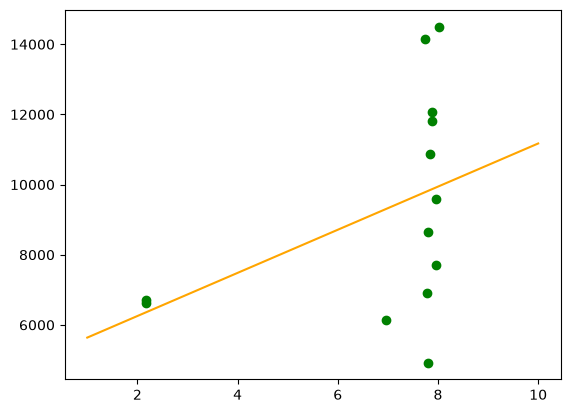

In [210]:
X = df_estatistica[['avaliacao']] 
y = df_estatistica['revpar']

modelo = LinearRegression() 
modelo.fit(X, y) 

X_ext = pd.DataFrame({'avaliacao': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}) 
y_pred = modelo.predict(X_ext)

plt.scatter(df_estatistica['avaliacao'], df_estatistica['revpar'],  color='green', label='Reais') 
plt.plot(X_ext, y_pred,  color='orange', label='Regressão') 
plt.show()

Estimativa entre Overbooking e Avaliação

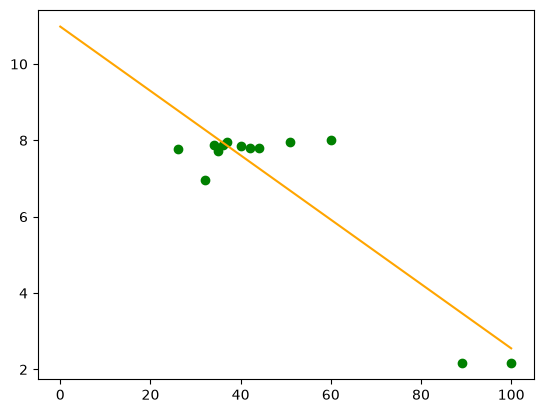

In [211]:
X = df_estatistica_excedentes[['hospedes_excedentes']]
y = df_estatistica_excedentes['avaliacao']

modelo = LinearRegression() 
modelo.fit(X, y) 

X_ext = pd.DataFrame({'hospedes_excedentes': [0, 20, 40, 60, 80, 100]})
y_pred = modelo.predict(X_ext)

plt.scatter(df_estatistica_excedentes['hospedes_excedentes'], df_estatistica_excedentes['avaliacao'], color='green', label='Reais')
plt.plot(X_ext, y_pred,  color='orange', label='Regressão') 
plt.show()

#### 6. Variabilidade regional do faturamento

* Faturamento total por região e por cidade.

* Coeficiente de variação por região (desvio padrão ÷ média), para comparar a instabilidade relativa do faturamento entre regiões de portes diferentes.

* Apesar do cáculo inicial do faturamento mensal, optamos por utilizar no cálculo abaixo, 
a `variável reservas realizadas` que restringe os valores somente às reservas `confirmadas` e `concluidas`

In [212]:
reservas_realizadas['mes'] = reservas_realizadas['data_checkin'].dt.month

faturamento_mensal_regiao = reservas_realizadas.groupby(['regiao', 'mes'])['faturamento'].sum().reset_index()
faturamento_mensal_unidade = reservas_realizadas.groupby(['nome_unidade', 'mes'])['faturamento'].sum().reset_index()

media_regiao = faturamento_mensal_regiao.groupby('regiao')['faturamento'].mean()
desvio_regiao = faturamento_mensal_regiao.groupby('regiao')['faturamento'].std()
coef_variacao_regiao = (desvio_regiao / media_regiao * 100).round(2)

media_unidade = faturamento_mensal_unidade.groupby('nome_unidade')['faturamento'].mean()
desvio_unidade = faturamento_mensal_unidade.groupby('nome_unidade')['faturamento'].std()
coef_variacao_unidades = (desvio_unidade / media_unidade * 100).round(2)

print("\n-------- Faturamento médio mensal por região  ---")
display(media_regiao.apply(converte_moeda))

print("\n-------- Faturamento médio mensal por unidades ---")
display(media_unidade.apply(converte_moeda))

print("--------- Coef. de V do Faturamento por Região ---")
display(coef_variacao_regiao.sort_values(ascending=False))

print("\n-------- Coef. de Variação do Faturamento por Unidade ---")
display(coef_variacao_unidades.sort_values(ascending=False))


-------- Faturamento médio mensal por região  ---


regiao
Baixada Fluminense     R$ 83.214.17
Capital               R$ 208.698.33
Costa Verde           R$ 170.710.00
Serra                 R$ 158.814.17
Name: faturamento, dtype: str


-------- Faturamento médio mensal por unidades ---


nome_unidade
NaraHoteis Angra dos Reis        R$ 51.718.33
NaraHoteis Barra da Tijuca       R$ 49.258.33
NaraHoteis Centro                R$ 33.160.83
NaraHoteis Copacabana Premium    R$ 22.279.09
NaraHoteis Friburgo              R$ 54.120.00
NaraHoteis Ipanema               R$ 51.465.83
NaraHoteis Mangaratiba           R$ 58.973.33
NaraHoteis Nova Iguaçu Centro    R$ 27.914.17
NaraHoteis Nova Iguaçu Park      R$ 55.300.00
NaraHoteis Paraty                R$ 60.018.33
NaraHoteis Petrópolis            R$ 50.399.17
NaraHoteis Santa Teresa          R$ 54.390.83
NaraHoteis Teresópolis           R$ 54.295.00
Name: faturamento, dtype: str

--------- Coef. de V do Faturamento por Região ---


regiao
Baixada Fluminense    44.39
Capital               40.40
Serra                 27.50
Costa Verde           14.27
Name: faturamento, dtype: float64


-------- Coef. de Variação do Faturamento por Unidade ---


nome_unidade
NaraHoteis Copacabana Premium    170.36
NaraHoteis Nova Iguaçu Centro    108.60
NaraHoteis Centro                101.39
NaraHoteis Petrópolis             38.86
NaraHoteis Barra da Tijuca        37.41
NaraHoteis Santa Teresa           34.43
NaraHoteis Friburgo               32.34
NaraHoteis Teresópolis            31.95
NaraHoteis Nova Iguaçu Park       29.12
NaraHoteis Mangaratiba            26.80
NaraHoteis Angra dos Reis         26.11
NaraHoteis Paraty                 26.11
NaraHoteis Ipanema                19.97
Name: faturamento, dtype: float64

### Projeção Gráfica

Projeção de métricas estatísticas: curtose e assimetria

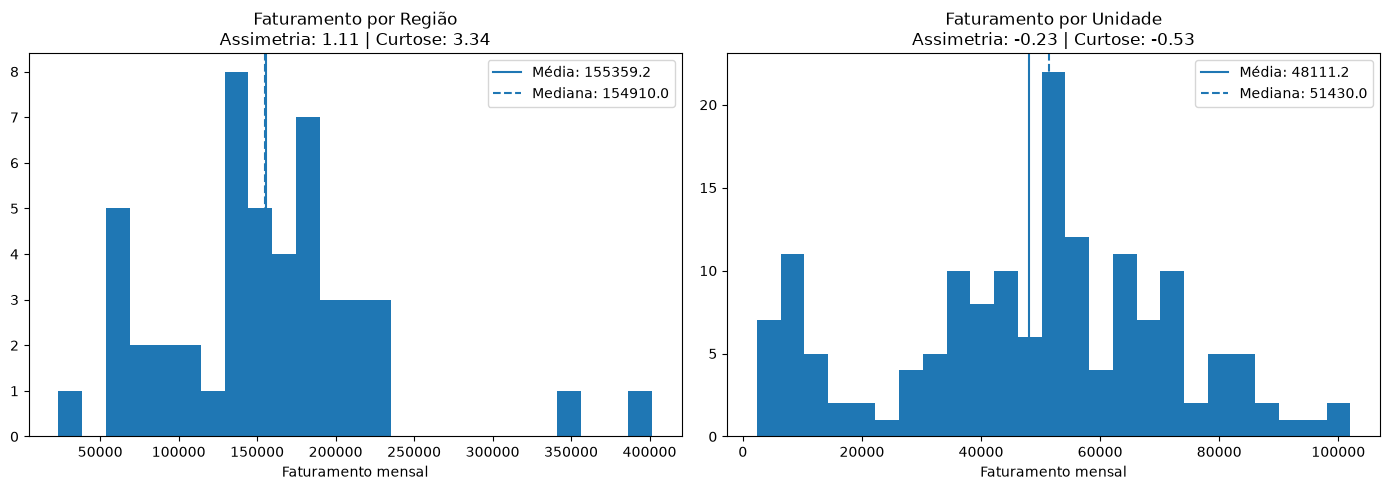

In [213]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(faturamento_mensal_regiao['faturamento'], bins=25)

axes[0].axvline(
    faturamento_mensal_regiao['faturamento'].mean(),
    label=f"Média: {faturamento_mensal_regiao['faturamento'].mean():.1f}"
)

axes[0].axvline(
    faturamento_mensal_regiao['faturamento'].median(),
    linestyle='--',
    label=f"Mediana: {faturamento_mensal_regiao['faturamento'].median():.1f}"
)

axes[0].set_title(
    f"Faturamento por Região\n"
    f"Assimetria: {faturamento_mensal_regiao['faturamento'].skew():.2f} | "
    f"Curtose: {faturamento_mensal_regiao['faturamento'].kurt():.2f}"
)

axes[0].set_xlabel('Faturamento mensal')
axes[0].legend()

axes[1].hist(faturamento_mensal_unidade['faturamento'], bins=25)

axes[1].axvline(
    faturamento_mensal_unidade['faturamento'].mean(),
    label=f"Média: {faturamento_mensal_unidade['faturamento'].mean():.1f}"
)

axes[1].axvline(
    faturamento_mensal_unidade['faturamento'].median(),
    linestyle='--',
    label=f"Mediana: {faturamento_mensal_unidade['faturamento'].median():.1f}"
)

axes[1].set_title(
    f"Faturamento por Unidade\n"
    f"Assimetria: {faturamento_mensal_unidade['faturamento'].skew():.2f} | "
    f"Curtose: {faturamento_mensal_unidade['faturamento'].kurt():.2f}"
)

axes[1].set_xlabel('Faturamento mensal')
axes[1].legend()

plt.tight_layout()
plt.show()

Gráfico de Faturamento Mensal Por Região e Unidade

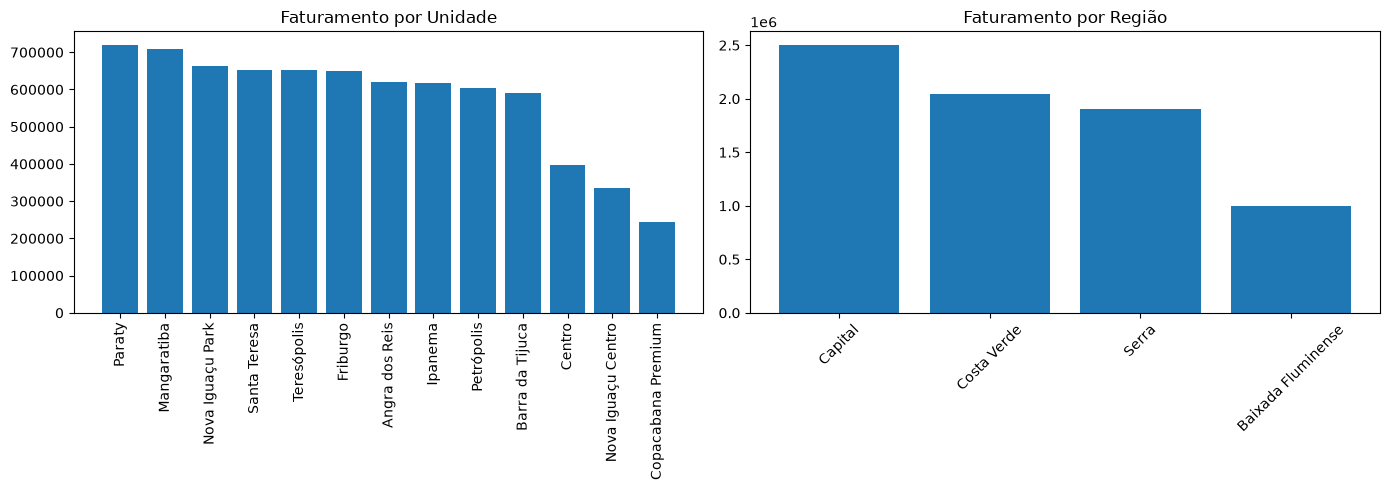

In [214]:
faturamento_unidade.index = (
    faturamento_unidade.index
    .str.replace('NaraHoteis ', '', regex=False))

fig1, eixos1 = plt.subplots(1, 2, figsize=(14, 5))

eixos1[0].bar(faturamento_unidade.index, faturamento_unidade.values)
eixos1[0].set_title('Faturamento por Unidade')
eixos1[0].tick_params(axis='x', rotation=90)

eixos1[1].bar(faturamento_regiao.index, faturamento_regiao.values)
eixos1[1].set_title('Faturamento por Região')
eixos1[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Execedentes X Avaliação

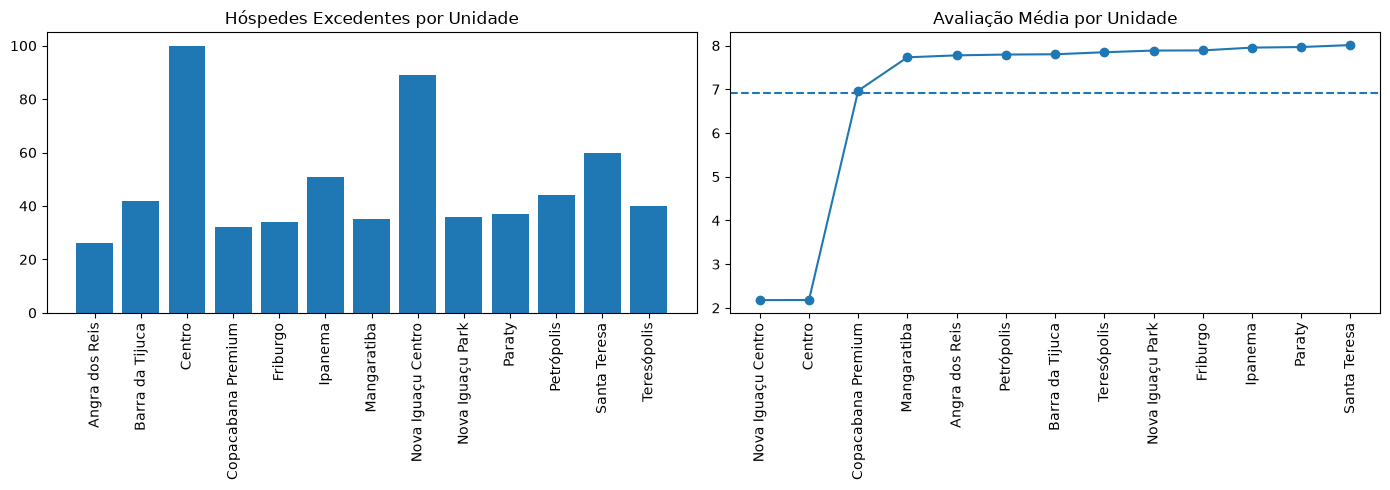

In [215]:
fig2, eixos2 = plt.subplots(1, 2, figsize=(14, 5))

eixos2[0].bar(
    total_excedente_por_unidade.index.str.replace('NaraHoteis ', '', regex=False), 
    total_excedente_por_unidade.values)
eixos2[0].set_title('Hóspedes Excedentes por Unidade')
eixos2[0].tick_params(axis='x', rotation=90)

avaliacao_ordenada = avaliacao_unidade.sort_values()

avaliacao_ordenada.index = (
    avaliacao_ordenada.index
    .str.replace('NaraHoteis ', '', regex=False))

eixos2[1].plot(avaliacao_ordenada.index, avaliacao_ordenada.values, marker='o')
eixos2[1].axhline(y=avaliacao_unidade.mean(), linestyle='--')
eixos2[1].set_title('Avaliação Média por Unidade')
eixos2[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()